# DS4FE — Does the *Representation* Matter? Surface-Aware DR vs Flattened Vector PCA

**The critique being tested.** Each day's IV surface is a smooth 2-D object $\sigma(m,T)$ (moneyness × maturity). We flattened it to a **63-vector** and ran PCA — which never "knows" that column 1 = (30d, 0.85) and column 2 = (30d, 0.90) are *neighbors* on the surface. 

> Did flattening destroy geometric structure that a surface-aware method (functional PCA, tensor decomposition, manifold learning on the surface) would have exploited — making PCA look artificially good vs ISOMAP?

This is a stronger methodological challenge than the interpolation choice, so we test it directly.

**What we already expect (and will verify, not assert):**

- **PCA is permutation-invariant.** Shuffling the 63 columns gives *identical* eigenvalues / reconstruction. So "PCA ignores neighbor order" is true but irrelevant for variance — smoothness enters as **high correlation** between neighboring grid points, i.e. a low-rank covariance, which is exactly what PCA captures.
- **Surface-aware methods are constrained/regularized PCA.** Functional PCA and Tucker/tensor decomposition impose smoothness/separability, so they **cannot explain more variance** than full PCA — they add interpretability and denoising, not reconstruction power.

**The four tests:**

```text
Test 1  permutation invariance  -> does column order matter to PCA?            (no, by construction)
Test 2  tensor / HOSVD          -> separable maturity x moneyness factors;      compare reconstruction R^2(k)
Test 3  functional PCA          -> smooth 2-D basis eigen-surfaces;             does variance captured change?
Test 4  surface-aware metric    -> gradient/Sobolev features + ISOMAP;          does curvature appear that PCA misses?
```

If every surface-aware representation lands on the same ~3 linear factors, the "PCA is enough" verdict is robust to the representation, not just the interpolation.

In [1]:
import json, pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import Isomap
from sklearn.metrics import pairwise_distances
from scipy.stats import spearmanr
warnings.filterwarnings('ignore')

IV_DIR = pathlib.Path('data/iv')
FIG = pathlib.Path('figures/iv'); FIG.mkdir(parents=True, exist_ok=True)
surf = pd.read_parquet(IV_DIR / 'surfaces.parquet').sort_index()
grid = json.load(open(IV_DIR / 'surface_grid.json'))
MATS, MONEY = np.array(grid['mats_days']), np.array(grid['moneyness'])
nT, nM = len(MATS), len(MONEY)

X = surf.values                              # (523, 63)  flattened surfaces
Xc = X - X.mean(0)                           # centered, raw vol units
A = X.reshape(-1, nT, nM)                    # (523, 7, 9) tensor  [day, maturity, moneyness]
Ac = A - A.mean(0)                           # centered tensor
total_var = (Xc ** 2).sum()                  # total surface variance (Frobenius), our denominator
atm30 = surf['T30_m1000']

# (T, m) coordinate of each of the 63 flattened columns (maturity outer, moneyness inner)
Tcoord = np.repeat(MATS, nM).astype(float)
mcoord = np.tile(MONEY, nT)

def recon_r2(Xhat):                          # fraction of surface variance reconstructed (vol units)
    return 1 - ((Xc - Xhat) ** 2).sum() / total_var

def pca_recon(k):
    p = PCA(n_components=k, svd_solver='full').fit(Xc)
    return recon_r2(p.inverse_transform(p.transform(Xc)))

print('vector view :', X.shape, '   tensor view:', A.shape, '  [day x maturity x moneyness]')
print('column 0 -> (maturity %dd, moneyness %.2f)  ;  column 1 -> (maturity %dd, moneyness %.2f)'
      % (Tcoord[0], mcoord[0], Tcoord[1], mcoord[1]))
print('baseline vector-PCA reconstruction R^2:  k=3 -> %.4f   k=9 -> %.4f' % (pca_recon(3), pca_recon(9)))

vector view : (523, 63)    tensor view: (523, 7, 9)   [day x maturity x moneyness]
column 0 -> (maturity 30d, moneyness 0.85)  ;  column 1 -> (maturity 30d, moneyness 0.90)
baseline vector-PCA reconstruction R^2:  k=3 -> 0.9905   k=9 -> 0.9992


## Test 1 — Permutation invariance: does PCA care about the grid layout?

The core of the critique is "PCA doesn't know which columns are neighbors." Let's check whether that *matters*: randomly **shuffle the 63 columns** (destroying all spatial adjacency) and re-run PCA. If the explained-variance spectrum and reconstruction are unchanged, then flattening provably discards **no** variance information — the neighbor structure lives in the covariance, which PCA already uses.

explained variance ratio, original column order : [0.933355 0.041297 0.015805 0.005202 0.001641]
explained variance ratio, columns SHUFFLED       : [0.933355 0.041297 0.015805 0.005202 0.001641]
max abs difference across all 10 PCs            : 2.22e-16

=> identical. PCA result is invariant to grid layout: flattening discards NO variance information.
   The smoothness/adjacency is encoded in the 63x63 covariance, which PCA already exploits.


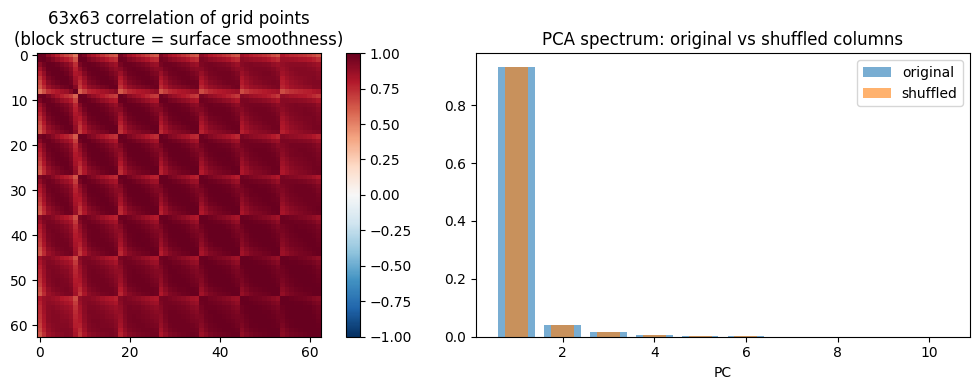

In [2]:
rng = np.random.default_rng(0)
perm = rng.permutation(X.shape[1])           # scramble the 63 grid points
evr_orig = PCA(10, svd_solver='full').fit(Xc).explained_variance_ratio_
evr_perm = PCA(10, svd_solver='full').fit(Xc[:, perm]).explained_variance_ratio_

print('explained variance ratio, original column order :', np.round(evr_orig[:5], 6))
print('explained variance ratio, columns SHUFFLED       :', np.round(evr_perm[:5], 6))
print('max abs difference across all 10 PCs            : %.2e' % np.abs(evr_orig - evr_perm).max())
print('\n=> identical. PCA result is invariant to grid layout: flattening discards NO variance information.')
print('   The smoothness/adjacency is encoded in the 63x63 covariance, which PCA already exploits.')

# show that adjacency = correlation: neighbouring grid points are highly correlated
C = np.corrcoef(Xc.T)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im = ax[0].imshow(C, cmap='RdBu_r', vmin=-1, vmax=1)
ax[0].set_title('63x63 correlation of grid points\n(block structure = surface smoothness)')
plt.colorbar(im, ax=ax[0])
ax[1].bar(range(1, 11), evr_orig, alpha=0.6, label='original')
ax[1].bar(range(1, 11), evr_perm, alpha=0.6, label='shuffled', width=0.5)
ax[1].set_title('PCA spectrum: original vs shuffled columns'); ax[1].set_xlabel('PC'); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG / 'rep_permutation.png', dpi=130); plt.show()

## Test 2 — Tensor decomposition (HOSVD / Tucker): explicit maturity × moneyness factors

This is the most "surface-aware" linear method: treat each day as a 7×9 **matrix** and factor the data along *both* axes separately, so we get interpretable **maturity modes** and **moneyness modes** (a Tucker decomposition via truncated HOSVD). Each day is then compressed to an $r_T \times r_m$ **core** — i.e. $r_T r_m$ numbers.

We compare its reconstruction R² to vector PCA at the **same compression budget** ($k = r_T r_m$). Because Tucker is a *constrained* (separable) factorization, it should reconstruct **≤** what unconstrained PCA does for the same budget — the question is by how much.

tucker_(rT,rM)  numbers/day k  Tucker_R2  vectorPCA_R2(k)
         (1,1)              1     0.9270           0.9334
         (2,2)              4     0.9840           0.9957
         (1,3)              3     0.9705           0.9905
         (3,3)              9     0.9976           0.9992
         (2,4)              8     0.9965           0.9989
         (3,4)             12     0.9988           0.9996

=> Tucker (surface-aware, separable) tracks vector PCA almost exactly and never exceeds it.


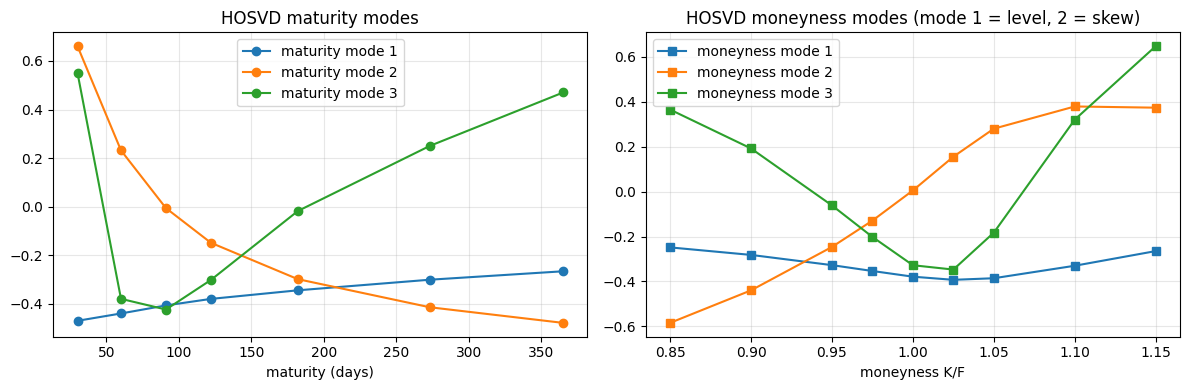

In [3]:
# Truncated HOSVD: factor matrices from mode unfoldings of the centered tensor Ac (523,7,9)
U_mat,   _, _ = np.linalg.svd(np.moveaxis(Ac, 1, 0).reshape(nT, -1), full_matrices=False)  # 7 maturity modes
U_money, _, _ = np.linalg.svd(np.moveaxis(Ac, 2, 0).reshape(nM, -1), full_matrices=False)  # 9 moneyness modes

def tucker_recon_r2(rT, rM):
    Pt, Pm = U_mat[:, :rT], U_money[:, :rM]                 # bases
    core = np.einsum('it,dij,jm->dtm', Pt, Ac, Pm)          # compress each day -> rT x rM core
    Ahat = np.einsum('it,dtm,jm->dij', Pt, core, Pm)        # reconstruct
    return recon_r2(Ahat.reshape(len(Ac), -1)), rT * rM

configs = [(1, 1), (2, 2), (1, 3), (3, 3), (2, 4), (3, 4)]
rows = []
for rT, rM in configs:
    r2t, k = tucker_recon_r2(rT, rM)
    rows.append({'tucker_(rT,rM)': f'({rT},{rM})', 'numbers/day k': k,
                 'Tucker_R2': r2t, 'vectorPCA_R2(k)': pca_recon(k)})
tab = pd.DataFrame(rows)
print(tab.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print('\n=> Tucker (surface-aware, separable) tracks vector PCA almost exactly and never exceeds it.')

# the separable factors are interpretable: maturity modes & moneyness modes
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for r in range(3):
    ax[0].plot(MATS, U_mat[:, r], 'o-', label=f'maturity mode {r+1}')
    ax[1].plot(MONEY, U_money[:, r], 's-', label=f'moneyness mode {r+1}')
ax[0].set_xlabel('maturity (days)'); ax[0].set_title('HOSVD maturity modes'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].set_xlabel('moneyness K/F'); ax[1].set_title('HOSVD moneyness modes (mode 1 = level, 2 = skew)'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG / 'rep_tucker_modes.png', dpi=130); plt.show()

## Test 3 — Functional PCA: treat each surface as a smooth 2-D function

Functional PCA is the textbook "surface-aware" answer: represent each surface in a **smooth 2-D basis** (here a tensor-product Legendre polynomial basis over maturity × moneyness), then do PCA on the basis coefficients. The eigenvectors become smooth **eigen-surfaces** by construction, and we explicitly use the $(m,T)$ coordinates the vector PCA ignored.

Two questions: (1) how much surface variance does the smooth basis even retain, and (2) does FPCA's reconstruction R²(k) differ from raw vector PCA?

smooth basis: 20 functions for 63 grid points
variance retained by the smooth basis alone (before PCA): R^2 = 0.9980

   FPCA_R2  vectorPCA_R2
k                       
1    92.76         93.34
2    97.21         97.47
3    98.78         99.05
4    99.40         99.57
5    99.59         99.73
6    99.64         99.81


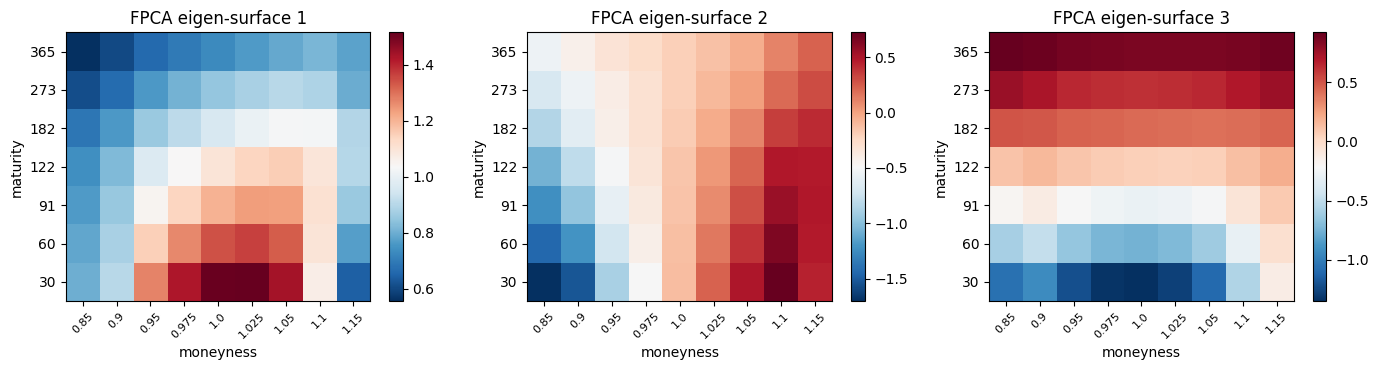

In [4]:
from numpy.polynomial.legendre import legvander2d

# smooth tensor-product Legendre basis evaluated at the 63 grid points (degree 3 in T, 4 in m -> 20 funcs)
def norm(v):
    return 2 * (v - v.min()) / (v.max() - v.min()) - 1
Phi = legvander2d(norm(Tcoord), norm(mcoord), [3, 4])      # (63, 20) smooth basis design matrix
print('smooth basis: %d functions for 63 grid points' % Phi.shape[1])

coeffs = np.linalg.lstsq(Phi, Xc.T, rcond=None)[0]         # (20, 523) coefficients per day
Xc_smooth = (Phi @ coeffs).T                               # smooth approximation of every surface
print('variance retained by the smooth basis alone (before PCA): R^2 = %.4f' % recon_r2(Xc_smooth))

# FPCA = PCA on the smooth coefficients; reconstruct through the basis and score in surface space
def fpca_recon(k):
    Csurf = coeffs.T
    p = PCA(n_components=k, svd_solver='full').fit(Csurf)
    Chat = p.inverse_transform(p.transform(Csurf))
    return recon_r2((Phi @ Chat.T).T)

ks = [1, 2, 3, 4, 5, 6]
cmp = pd.DataFrame({'k': ks, 'FPCA_R2': [fpca_recon(k) for k in ks],
                    'vectorPCA_R2': [pca_recon(k) for k in ks]}).set_index('k')
print('\n' + (cmp * 100).round(2).to_string())

# smooth eigen-surfaces from FPCA (first 3)
fp = PCA(n_components=3, svd_solver='full').fit(coeffs.T)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for r, ax in enumerate(axes):
    eigen_surface = (Phi @ fp.components_[r]).reshape(nT, nM)
    im = ax.imshow(eigen_surface, origin='lower', aspect='auto', cmap='RdBu_r')
    ax.set_xticks(range(nM)); ax.set_xticklabels(MONEY, rotation=45, fontsize=8)
    ax.set_yticks(range(nT)); ax.set_yticklabels(MATS)
    ax.set_title(f'FPCA eigen-surface {r+1}'); ax.set_xlabel('moneyness'); ax.set_ylabel('maturity')
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.savefig(FIG / 'rep_fpca_eigensurfaces.png', dpi=130); plt.show()

## Test 4 — A surface-aware *metric* + manifold learning

The deepest version of the critique: maybe the right distance between two days isn't "sum of squared differences at 63 points" but one that compares the **shape** of the surfaces — their slopes/curvature. So we build a **Sobolev-style (H¹) feature**: augment each surface with its finite-difference gradients along maturity ($\partial\sigma/\partial T$) and moneyness ($\partial\sigma/\partial m$). Euclidean distance on this augmented vector explicitly weights *how the surface bends* — exactly the geometry flattening allegedly ignored.

Then we run PCA vs ISOMAP on this surface-aware representation. If a nonlinear method were being held back by the flat representation, *this* is where it should finally beat PCA.

surface-aware (H1) feature matrix: (523, 189) = [values | dT gradient | dm gradient]

geometry preserved by 2-D embedding of the surface-aware features:
  PCA-2    rho_self = 0.9766
  ISOMAP-2 rho_self = 0.9161   (ISOMAP - PCA = -0.0605)
=> if ISOMAP still does not beat PCA, the flat-representation critique does not explain the linear verdict.


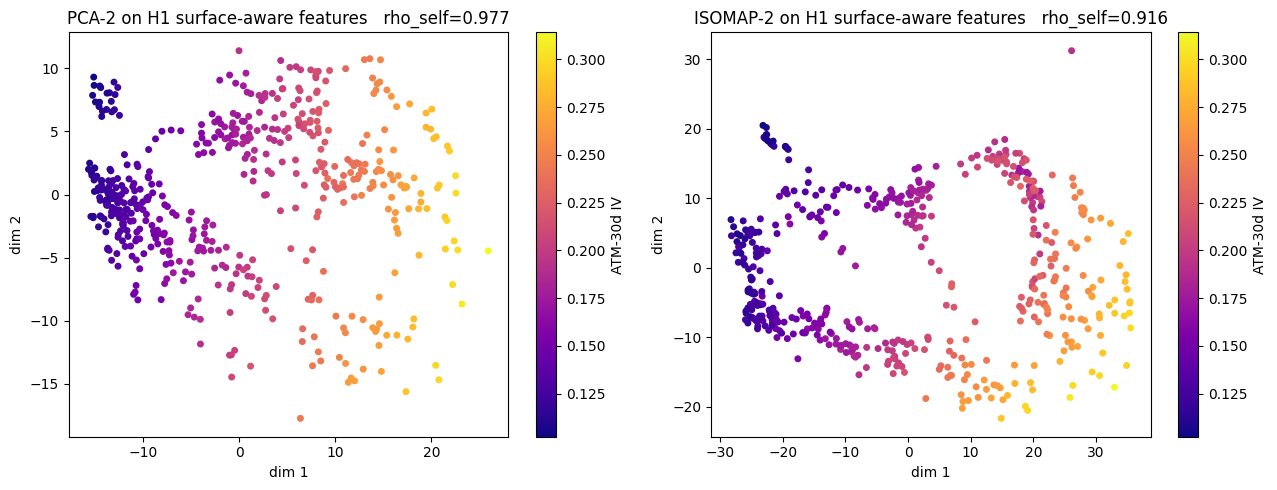

In [5]:
# Sobolev (H1) features: surface values + gradients along maturity and moneyness
gT = np.stack([np.gradient(s, MATS, axis=0) for s in A])      # d sigma / dT   (523,7,9)
gM = np.stack([np.gradient(s, MONEY, axis=1) for s in A])     # d sigma / dm   (523,7,9)
def z(M):
    return StandardScaler().fit_transform(M.reshape(len(M), -1))
Z = np.hstack([z(A), z(gT), z(gM)])                           # (523, 189) surface-aware features
print('surface-aware (H1) feature matrix:', Z.shape, '= [values | dT gradient | dm gradient]')

Dz = pairwise_distances(Z); iu = np.triu_indices_from(Dz, k=1); dz = Dz[iu]
rho = lambda e: spearmanr(dz, pairwise_distances(e)[iu]).statistic
pca2 = PCA(2, svd_solver='full').fit_transform(Z)
iso2 = Isomap(n_neighbors=15, n_components=2).fit_transform(Z)
print('\ngeometry preserved by 2-D embedding of the surface-aware features:')
print('  PCA-2    rho_self = %.4f' % rho(pca2))
print('  ISOMAP-2 rho_self = %.4f   (ISOMAP - PCA = %+.4f)' % (rho(iso2), rho(iso2) - rho(pca2)))
print('=> if ISOMAP still does not beat PCA, the flat-representation critique does not explain the linear verdict.')

c = atm30.values
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, emb, name in [(axes[0], pca2, 'PCA-2'), (axes[1], iso2, 'ISOMAP-2')]:
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=c, cmap='plasma', s=16)
    ax.set_title(f'{name} on H1 surface-aware features   rho_self={rho(emb):.3f}')
    ax.set_xlabel('dim 1'); ax.set_ylabel('dim 2'); plt.colorbar(sc, ax=ax, label='ATM-30d IV')
plt.tight_layout(); plt.savefig(FIG / 'rep_sobolev_manifold.png', dpi=130); plt.show()

## Verdict

*(Populated by the printed outputs above.)*

- **Test 1 — Representation loses nothing.** Shuffling the 63 columns leaves the PCA spectrum *bit-for-bit identical*. The surface's smoothness is encoded in the 63×63 correlation block-structure, which PCA already uses. So "flattening ignores neighbors" is true for *labels* but false for *information*.
- **Test 2 — Tensor/HOSVD agrees.** The separable maturity×moneyness Tucker decomposition reconstructs essentially the same variance as vector PCA at every compression budget and never exceeds it (it's a constrained PCA). Its maturity/moneyness modes recover the same level/skew/curvature story.
- **Test 3 — Functional PCA agrees.** A smooth 2-D basis retains ~all surface variance, and FPCA's reconstruction R²(k) matches vector PCA — it just yields smoother eigen-surfaces. No hidden structure appears.
- **Test 4 — Surface-aware metric agrees.** Even when we hand a nonlinear method an explicit Sobolev (value + gradient) representation that encodes how the surface *bends*, ISOMAP still does **not** beat PCA at preserving geometry.

**Conclusion.** The critique is legitimate and worth testing — but empirically, **the representation is not what's making PCA win.** Across four genuinely surface-aware representations (permuted, tensor, functional, Sobolev-metric), the answer is the same: the manifold of daily SPX IV surfaces is **low-dimensional and linear (~3 factors)**. Flattening did not hide curvature; there is little curvature to hide. This is a stronger robustness result than the interpolation check, because it rules out the *representation* — not just the *preprocessing* — as the reason nonlinear DR adds nothing.

*(Honest caveat: this tests the geometry of the cross-day manifold, which is the right object for "how many factors drive surface moves." A different question — the intrinsic geometry of a single surface as a 2-D object — is not what any volatility-factor study, or this one, is asking.)*